# GSE140228: PGAM5-associated macrophage differential expression in all Tumor samples

Scope is literal author `Tissue == Tumor`, including every Tumor sample and all six original `celltype_sub` macrophage labels beginning `Mφ-`. Normal, Blood, Ascites and Lymphnode are excluded. Droplet and Smart-seq2 are analyzed separately because their matrices contain UMI counts and read counts, respectively. **Author Histology labels include CC in Droplet; this is an all-Tumor analysis, not an HCC-only analysis.** Counts of samples must not be interpreted as counts of independent patients; a donor may provide several specimens and occur in both technologies.

## Method and assumptions

PGAM5 raw count >0 defines detected cells; count=0 means RNA nondetection, not protein negativity. QC retains cells with >=500 detected genes and <20% mitochondrial counts. Counts are normalized to 10,000 per cell and log1p transformed. Within each platform, all retained Tumor macrophages are pooled for two-group Wilcoxon tests with tie correction and BH across all genes. No patient pairing, depth matching or sample/depth covariates are used, following the requested analysis.

Candidate thresholds: **FDR <0.05, |Scanpy approximate log2FC| >=1, detection in >=10% of either group**. PGAM5 remains in full DE and threshold-passing tables but is excluded from up/down candidate tables. Ribosomal and mitochondrial genes remain eligible. The approximate log2FC is the ratio of back-transformed mean log expression, not the ratio of arithmetic means. Large fold changes against near-zero controls can reflect pseudocount sensitivity.

These are exploratory associations. Cell-level FDR does not establish reproducibility across patients. Depth, histology and macrophage subtype differences can contribute to the results because the requested tests do not adjust for them. No causal mechanism, validated signature, independent cross-platform replication, ambient-RNA correction or doublet removal is claimed.

Source: [GEO series](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE140228), [official supplementary files](https://ftp.ncbi.nlm.nih.gov/geo/series/GSE140nnn/GSE140228/suppl/); PMID 31675496. Input filenames and SHA256 hashes are retained in input_sha256.json. Barcode/metadata and count/gene row alignments are asserted in analyze_tumor.py.

The analysis script has been executed on source counts. This notebook independently verifies selected outputs against retained raw macrophage counts, then regenerates the figures.


In [1]:
from pathlib import Path
import json
import numpy as np,pandas as pd,anndata as ad
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from IPython.display import display
R=Path.cwd();summary={k:v for k,v in json.loads((R/'analysis_summary.json').read_text()).items() if k in ['Droplet','Smartseq2']}
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10,'axes.spines.top':False,'axes.spines.right':False,'figure.dpi':120,'savefig.bbox':'tight'})
rows=[];checks=[]
for tech,s in summary.items():
 p=R/tech;a=ad.read_h5ad(p/'macrophage_counts_QC.h5ad');r=pd.read_csv(p/'full_DE.csv',index_col=0)
 pos=a.obs.PGAM5_counts.to_numpy()>0
 assert a.obs.Tissue.eq('Tumor').all() and a.obs.celltype_sub.str.startswith('Mφ-').all()
 assert a.obs.n_genes.ge(500).all() and a.obs.pct_mt.lt(20).all()
 assert a.obs_names.is_unique and a.var_names.is_unique
 assert int(pos.sum())==s['PGAM5_positive'] and int((~pos).sum())==s['PGAM5_undetected']
 pg=np.flatnonzero(a.var.gene.eq('PGAM5'));assert len(pg)==1 and np.array_equal(a.X[:,pg[0]].toarray().ravel(),a.obs.PGAM5_counts)
 q=multipletests(r.p_value,method='fdr_bh')[1];assert np.allclose(q,r.FDR,atol=1e-12)
 for direction,sign in [('upregulated',1),('downregulated',-1)]:
  c=pd.read_csv(p/(direction+'.csv'),index_col=0)
  expected=r[r.FDR.lt(.05)&(r.log2FC*sign).ge(1)&r[['fraction_PGAM5_positive','fraction_PGAM5_undetected']].max(axis=1).ge(.1)&~r.gene.eq('PGAM5')]
  assert set(c.index)==set(expected.index)
 # Independent SciPy rank test on five strongest nondefining candidates, no continuity correction (Scanpy convention).
 ids=pd.read_csv(p/'upregulated.csv',index_col=0).index[:5]
 totals=np.asarray(a.X.sum(axis=1)).ravel()
 for gene_id in ids:
  j=a.var_names.get_loc(gene_id);counts=a.X[:,j].toarray().ravel()
  v=np.log1p(counts/totals*1e4)
  pv=mannwhitneyu(v[pos],v[~pos],alternative='two-sided',method='asymptotic',use_continuity=False).pvalue
  est=np.log2((np.expm1(v[pos].mean())+1e-9)/(np.expm1(v[~pos].mean())+1e-9))
  assert np.isclose(pv,r.loc[gene_id,'p_value'],rtol=.002,atol=1e-12)
  assert np.isclose(est,r.loc[gene_id,'log2FC'],atol=.002)
  assert np.isclose((counts[pos]>0).mean(),r.loc[gene_id,'fraction_PGAM5_positive'])
  checks.append({'platform':tech,'gene':r.loc[gene_id,'gene'],'SciPy_two_sided_p':pv,'Scanpy_p':r.loc[gene_id,'p_value'],'recomputed_log2FC':est,'reported_log2FC':r.loc[gene_id,'log2FC']})
 rows.append({'platform':tech,'Tumor samples':s['tumor_samples'],'Tumor donors':s['tumor_donors'],'Tumor cells':s['tumor_cells'],'QC macrophages':s['QC_macrophages'],'PGAM5+':s['PGAM5_positive'],'PGAM5 undetected':s['PGAM5_undetected'],'up':s['upregulated_excluding_PGAM5'],'down':s['downregulated_excluding_PGAM5']})
 del a
pd.DataFrame(checks).to_csv(R/'independent_calculation_checks.csv',index=False)
display(pd.DataFrame(rows));display(pd.DataFrame(checks))
print('Scope, identities, PGAM5 counts, BH correction, complete candidate sets and selected rank-test/fold-change calculations verified.')


,platform,Tumor samples,Tumor donors,Tumor cells,QC macrophages,PGAM5+,PGAM5 undetected,up,down
0,Droplet,8,5,18621,2508,60,2448,671,0
1,Smartseq2,10,6,2423,531,62,469,1637,4


,platform,gene,SciPy_two_sided_p,Scanpy_p,recomputed_log2FC,reported_log2FC
0,Droplet,ANGPTL4,2.969574e-21,2.969574e-21,3.089343,3.089343
1,Droplet,NEURL1B,4.298534e-17,4.298534e-17,3.882133,3.882133
2,Droplet,SMIM10,2.895984e-16,2.895984e-16,2.952721,2.952721
3,Droplet,DUSP14,7.634980e-16,7.634980e-16,2.726922,2.726922
4,Droplet,TSHZ2,1.938490e-14,1.938490e-14,2.623018,2.623018
5,Smartseq2,GPR37,6.653269e-17,6.653269e-17,5.042450,5.042450
6,Smartseq2,RP11-959F10.6,4.847678e-15,4.847678e-15,24.268909,24.268910
7,Smartseq2,IRS1,4.559351e-14,4.559351e-14,2.843272,2.843272
8,Smartseq2,AQP11,5.845818e-14,5.845818e-14,3.571669,3.571669
9,Smartseq2,RP11-67L3.5,4.141971e-13,4.141971e-13,5.225935,5.225935


Scope, identities, PGAM5 counts, BH correction, complete candidate sets and selected rank-test/fold-change calculations verified.


## Sample composition and PGAM5 detection

Rates use QC macrophages as the denominator. Labels include the author Histology annotation. Multiple specimens may share a donor; both platforms include D20171109. Sample tables retain counts and donor IDs for inspection.


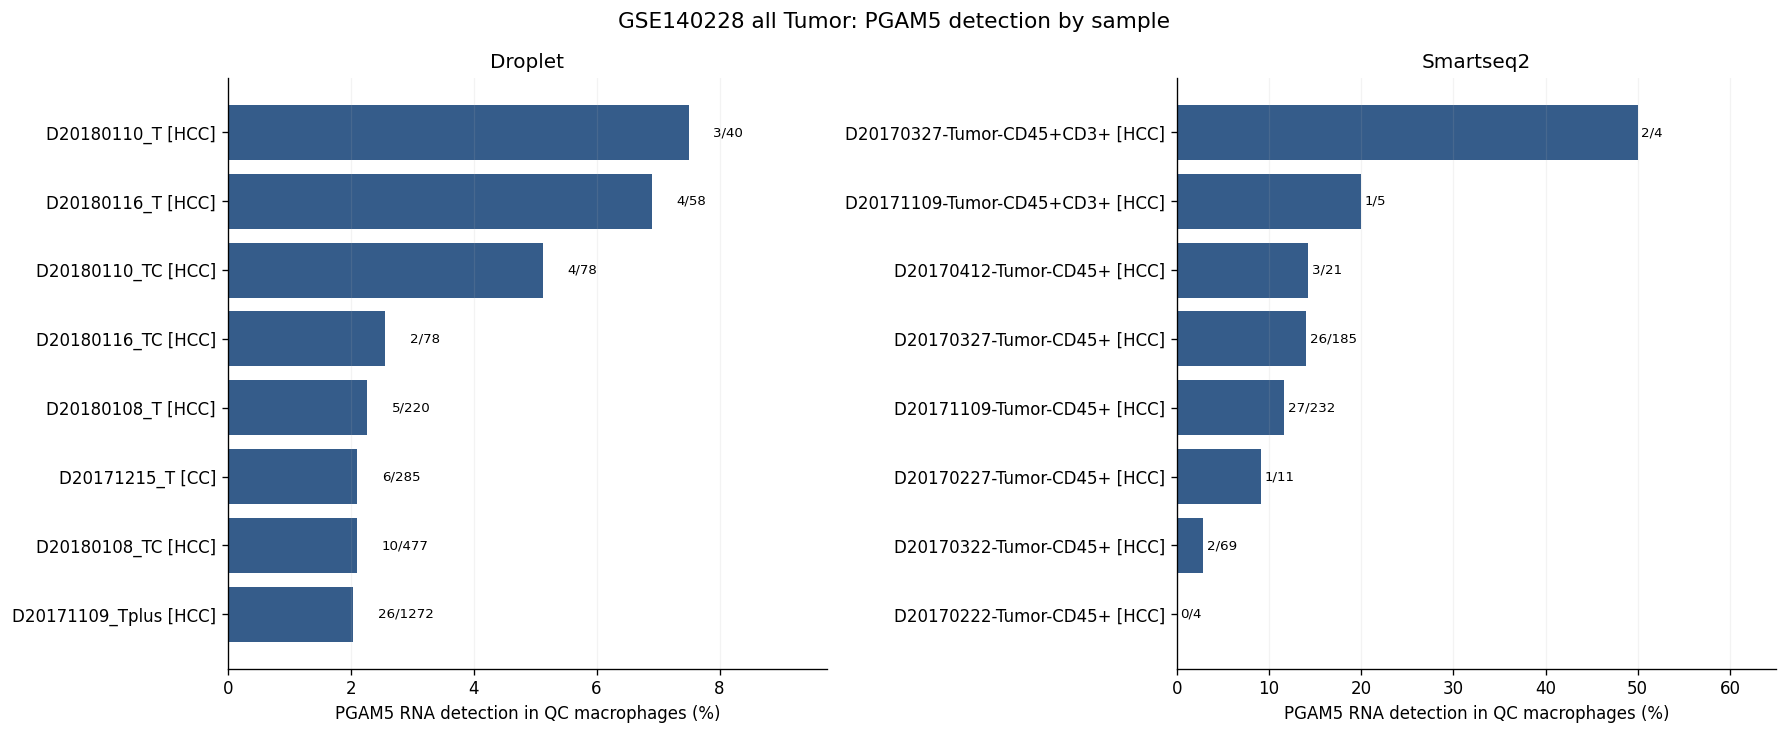

Droplet


,Sample,Donor,Histology,macrophages,PGAM5_positive,rate
0,D20171109_Tplus,D20171109,HCC,1272,26,0.020440
1,D20171215_T,D20171215,CC,285,6,0.021053
2,D20180108_T,D20180108,HCC,220,5,0.022727
3,D20180108_TC,D20180108,HCC,477,10,0.020964
4,D20180110_T,D20180110,HCC,40,3,0.075000
5,D20180110_TC,D20180110,HCC,78,4,0.051282
6,D20180116_T,D20180116,HCC,58,4,0.068966
7,D20180116_TC,D20180116,HCC,78,2,0.025641


QC histology: {'HCC': 2223, 'CC': 285}
Smartseq2


,Sample,Donor,Histology,macrophages,PGAM5_positive,rate
0,D20170222-Tumor-CD45+,D20170222,HCC,4,0,0.000000
1,D20170227-Tumor-CD45+,D20170227,HCC,11,1,0.090909
2,D20170322-Tumor-CD45+,D20170322,HCC,69,2,0.028986
3,D20170327-Tumor-CD45+,D20170327,HCC,185,26,0.140541
4,D20170327-Tumor-CD45+CD3+,D20170327,HCC,4,2,0.500000
5,D20170412-Tumor-CD45+,D20170412,HCC,21,3,0.142857
6,D20171109-Tumor-CD45+,D20171109,HCC,232,27,0.116379
7,D20171109-Tumor-CD45+CD3+,D20171109,HCC,5,1,0.200000


QC histology: {'HCC': 531}


In [2]:
fig,axes=plt.subplots(1,2,figsize=(15,6.2))
for ax,(tech,s) in zip(axes,summary.items()):
 t=pd.read_csv(R/tech/'PGAM5_by_sample.csv').sort_values('rate')
 labels=t.Sample+' ['+t.Histology+']';ax.barh(labels,t.rate*100,color='#355C8A')
 for i,(_,z) in enumerate(t.iterrows()):ax.text(z.rate*100+.4,i,f"{z.PGAM5_positive}/{z.macrophages}",va='center',fontsize=8)
 ax.set_xlim(0,max(5,t.rate.max()*100*1.30));ax.set_xlabel('PGAM5 RNA detection in QC macrophages (%)');ax.set_title(tech);ax.grid(axis='x',alpha=.15)
fig.suptitle('GSE140228 all Tumor: PGAM5 detection by sample',fontsize=13);fig.tight_layout();fig.savefig(R/'PGAM5_detection_by_sample.png');fig.savefig(R/'PGAM5_detection_by_sample.pdf');plt.show()
for tech in summary:
 print(tech);display(pd.read_csv(R/tech/'PGAM5_by_sample.csv'));print('QC histology:',summary[tech]['QC_macrophage_histology'])


## Differential expression

The volcano view includes genes detected in >=10% of either group. Orange marks upregulated candidates, blue marks downregulated candidates, and gray marks the remainder. PGAM5 is not plotted because it defines the comparison. Candidate counts and top genes are shown separately for each technology.


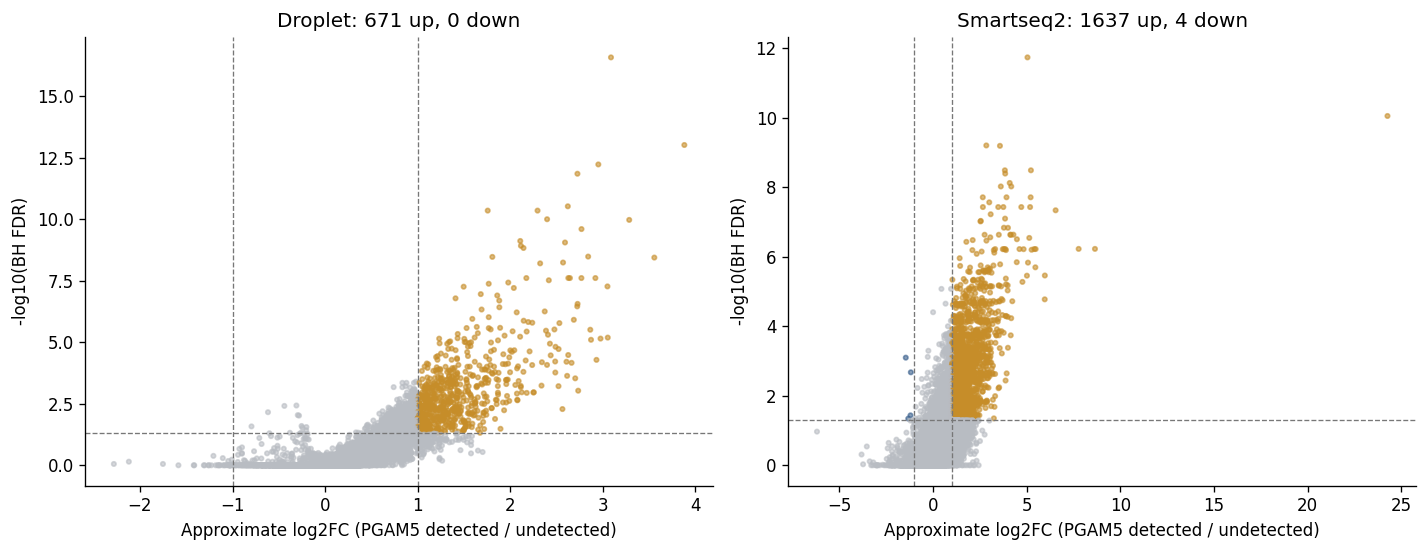

Droplet top up candidates


,gene,log2FC,FDR,fraction_PGAM5_positive,fraction_PGAM5_undetected
0,ANGPTL4,3.089343,2.701025e-17,0.133333,0.007353
1,NEURL1B,3.882133,9.774508e-14,0.116667,0.007353
2,SMIM10,2.952721,6.021992e-13,0.116667,0.007761
3,DUSP14,2.726922,1.436798e-12,0.166667,0.016748
4,TSHZ2,2.623018,3.022604e-11,0.116667,0.008987
5,AIFM2,2.295945,4.516238e-11,0.200000,0.026552
6,HDGF,1.757393,4.516238e-11,0.616667,0.194444
7,ZBTB22,2.399040,1.012957e-10,0.166667,0.019199
8,CCND1,3.286319,1.078283e-10,0.200000,0.028186
9,GUCY1A3,2.770677,2.541540e-10,0.216667,0.033088


Smartseq2 top up candidates


,gene,log2FC,FDR,fraction_PGAM5_positive,fraction_PGAM5_undetected
0,GPR37,5.042450,1.815478e-12,0.193548,0.006397
1,RP11-959F10.6,24.268910,8.818572e-11,0.129032,0.000000
2,IRS1,2.843272,6.220550e-10,0.225806,0.019190
3,AQP11,3.571669,6.380593e-10,0.225806,0.019190
4,RP11-67L3.5,5.225935,3.229199e-09,0.177419,0.010661
5,SLC22A25,3.834601,3.229199e-09,0.129032,0.002132
6,AMOTL2,3.851761,4.010672e-09,0.177419,0.010661
7,SUGCT,4.093610,7.478652e-09,0.209677,0.019190
8,SLC15A1,4.175962,9.416664e-09,0.161290,0.008529
9,RPL39P5,3.617770,9.416664e-09,0.161290,0.008529


In [3]:
fig,axes=plt.subplots(1,2,figsize=(12,4.7))
for ax,(tech,s) in zip(axes,summary.items()):
 r=pd.read_csv(R/tech/'full_DE.csv',index_col=0);r=r[r[['fraction_PGAM5_positive','fraction_PGAM5_undetected']].max(axis=1).ge(.1)&~r.gene.eq('PGAM5')]
 color=np.where(r.FDR.lt(.05)&r.log2FC.ge(1),'#C68D29',np.where(r.FDR.lt(.05)&r.log2FC.le(-1),'#355C8A','#B8BCC2'))
 ax.scatter(r.log2FC,-np.log10(r.FDR.clip(lower=1e-300)),c=color,s=7,alpha=.6)
 ax.axhline(-np.log10(.05),ls='--',color='#777',lw=.8)
 for x in [-1,1]:ax.axvline(x,ls='--',color='#777',lw=.8)
 ax.set_xlabel('Approximate log2FC (PGAM5 detected / undetected)');ax.set_ylabel('-log10(BH FDR)');ax.set_title(f"{tech}: {s['upregulated_excluding_PGAM5']} up, {s['downregulated_excluding_PGAM5']} down")
fig.tight_layout();fig.savefig(R/'differential_expression.png');fig.savefig(R/'differential_expression.pdf');plt.show()
for tech in summary:
 print(tech,'top up candidates');display(pd.read_csv(R/tech/'top20_upregulated.csv')[['gene','log2FC','FDR','fraction_PGAM5_positive','fraction_PGAM5_undetected']])


## Original macrophage annotation checks

Detection fractions of macrophage and possible nonmyeloid transcripts are reported without post hoc removal of cells. Author macrophage annotations define the selected population; monocyte and dendritic cell labels are excluded. Some macrophages have ALB, CD3D, EPCAM or MS4A1 transcripts; ambient RNA, doublets and phagocytosed material are not distinguished.


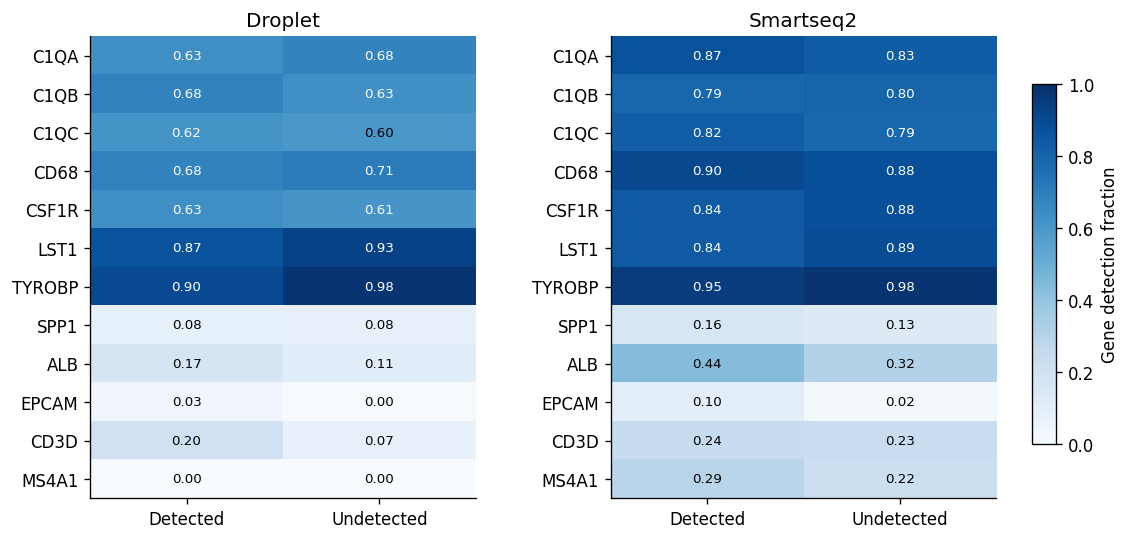

In [4]:
fig,axes=plt.subplots(1,2,figsize=(10,5))
markers=['C1QA','C1QB','C1QC','CD68','CSF1R','LST1','TYROBP','SPP1','ALB','EPCAM','CD3D','MS4A1']
for ax,tech in zip(axes,summary):
 q=pd.read_csv(R/tech/'marker_QA.csv').pivot(index='gene',columns='group',values='fraction').reindex(markers)
 im=ax.imshow(q.to_numpy(),vmin=0,vmax=1,cmap='Blues',aspect='auto');ax.set_yticks(range(len(q)),q.index);ax.set_xticks([0,1],['Detected','Undetected']);ax.set_title(tech)
 for i in range(len(q)):
  for j in range(2):
   z=q.iloc[i,j];ax.text(j,i,f'{z:.2f}',ha='center',va='center',color='white' if z>.6 else 'black',fontsize=8)
fig.subplots_adjust(right=.88,wspace=.35);cb=fig.add_axes([.91,.2,.02,.6]);fig.colorbar(im,cax=cb,label='Gene detection fraction');fig.savefig(R/'macrophage_marker_QA.png');fig.savefig(R/'macrophage_marker_QA.pdf');plt.show()


## Interpretation and reproducibility

Upregulated genes are candidate associations with PGAM5 RNA detection under the requested pooled-cell model. The all-Tumor Droplet result mixes HCC and CC histology and should not be labelled HCC-specific. Technology separation avoids mixing UMI and read count distributions but does not make platforms independent patient cohorts. A candidate intersection is a descriptive overlap, not independent validation.

Download the seven official .gz files into the script directory and run `python analyze_tumor.py` using versions listed in environment_versions.txt. The script locates inputs relative to itself. Run `python build_notebook.py` to execute this notebook and regenerate plots from outputs. All filtering, annotation, summary and calculation checks are explicit in the scripts and notebook. Raw source matrices and QC count matrices are not copied into the downloadable result ZIP. Input hashes and reproduction scripts are included; rerunning analyze_tumor.py generates the QC count matrices needed for notebook checks. Executed notebook outputs retain these checks.
